# Acquire and Explore Daily SPY Data

This notebook downloads daily SPY market data from Yahoo Finance,
preserves the original response, and loads the observations into pandas. 

Then, it performs and conducts exploratory data analysis on reloaded CSV files.

## Download SPY Daily Price Data

In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

from data_utils import fetch_yahoo_data
from data_utils import load_yahoo_data
from data_utils import save_fig

In [ ]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError(
        "Could not locate the project root containing pyproject.toml."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
SYMBOL = "SPY"

print(f"Project root: {PROJECT_ROOT}")
print(f"Symbol: {SYMBOL}")

Project root: /Users/tonyli/Desktop/hands-on-ml-experiment
Symbol: SPY


In [4]:
raw_prices, raw_path = fetch_yahoo_data(SYMBOL)

Downloaded 8,428 daily observations.
First date: 1993-01-29 00:00:00
Last date: 2026-07-24 00:00:00
Saved raw Yahoo data to: /Users/tonyli/Desktop/hands-on-ml-experiment/data/raw/yahoo_spy_daily_2026-07-26.csv
Removed 1 older raw data file(s).


## Explore SPY Daily Price Data

In [5]:
raw_prices = load_yahoo_data(SYMBOL)

In [6]:
print(f"\nNumber of rows: {len(raw_prices):,}")

print("Columns:")
print(raw_prices.columns.tolist())

print("\nData types:")
print(raw_prices.dtypes)

display(raw_prices.head())
display(raw_prices.tail())


Number of rows: 8,428
Columns:
['Adj Close', 'Capital Gains', 'Close', 'Dividends', 'High', 'Low', 'Open', 'Stock Splits', 'Volume']

Data types:
Adj Close        float64
Capital Gains    float64
Close            float64
Dividends        float64
High             float64
Low              float64
Open             float64
Stock Splits     float64
Volume             int64
dtype: object


,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,,
1993-01-29,24.113268,0.0,43.93750,0.0,43.96875,43.75000,43.96875,0.0,1003200
1993-02-01,24.284767,0.0,44.25000,0.0,44.25000,43.96875,43.96875,0.0,480500
1993-02-02,24.336208,0.0,44.34375,0.0,44.37500,44.12500,44.21875,0.0,201300
1993-02-03,24.593462,0.0,44.81250,0.0,44.84375,44.37500,44.40625,0.0,529400
1993-02-04,24.696379,0.0,45.00000,0.0,45.09375,44.46875,44.96875,0.0,531500


,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,,
2026-07-20,742.090027,0.0,742.090027,0.0,748.729980,741.510010,747.059998,0.0,50422300
2026-07-21,748.280029,0.0,748.280029,0.0,749.039978,744.179993,746.289978,0.0,34324300
2026-07-22,747.409973,0.0,747.409973,0.0,750.020020,746.369995,746.619995,0.0,32836200
2026-07-23,738.179993,0.0,738.179993,0.0,742.559998,735.210022,739.369995,0.0,55437300
2026-07-24,738.929993,0.0,738.929993,0.0,743.719971,737.289978,738.510010,0.0,44725600


In [7]:
raw_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 8428 entries, 1993-01-29 to 2026-07-24
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Adj Close      8428 non-null   float64
 1   Capital Gains  8428 non-null   float64
 2   Close          8428 non-null   float64
 3   Dividends      8428 non-null   float64
 4   High           8428 non-null   float64
 5   Low            8428 non-null   float64
 6   Open           8428 non-null   float64
 7   Stock Splits   8428 non-null   float64
 8   Volume         8428 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 658.4 KB


In [8]:
raw_prices.describe()

,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
count,8428.000000,8428.0,8428.000000,8428.000000,8428.000000,8428.000000,8428.000000,8428.0,8.428000e+03
mean,173.092839,0.0,203.814675,0.013228,204.968743,202.506341,203.796906,0.0,8.305756e+07
std,162.785684,0.0,156.304336,0.121721,157.015257,155.444028,156.265354,0.0,8.917988e+07
min,23.821701,0.0,43.406250,0.000000,43.531250,42.812500,43.343750,0.0,5.200000e+03
25%,70.866808,0.0,108.627499,0.000000,109.489998,107.574219,108.545315,0.0,1.287595e+07
50%,95.945251,0.0,136.531250,0.000000,137.316254,135.484375,136.509995,0.0,6.298375e+07
75%,233.225204,0.0,263.785004,0.000000,265.769997,262.087486,263.882500,0.0,1.101816e+08
max,757.618225,0.0,759.570007,1.993000,760.400024,756.750000,758.150024,0.0,8.710263e+08


## Visualize Variables in SPY Daily Price Data

Saving figure SPY_attribute_histogram_plots


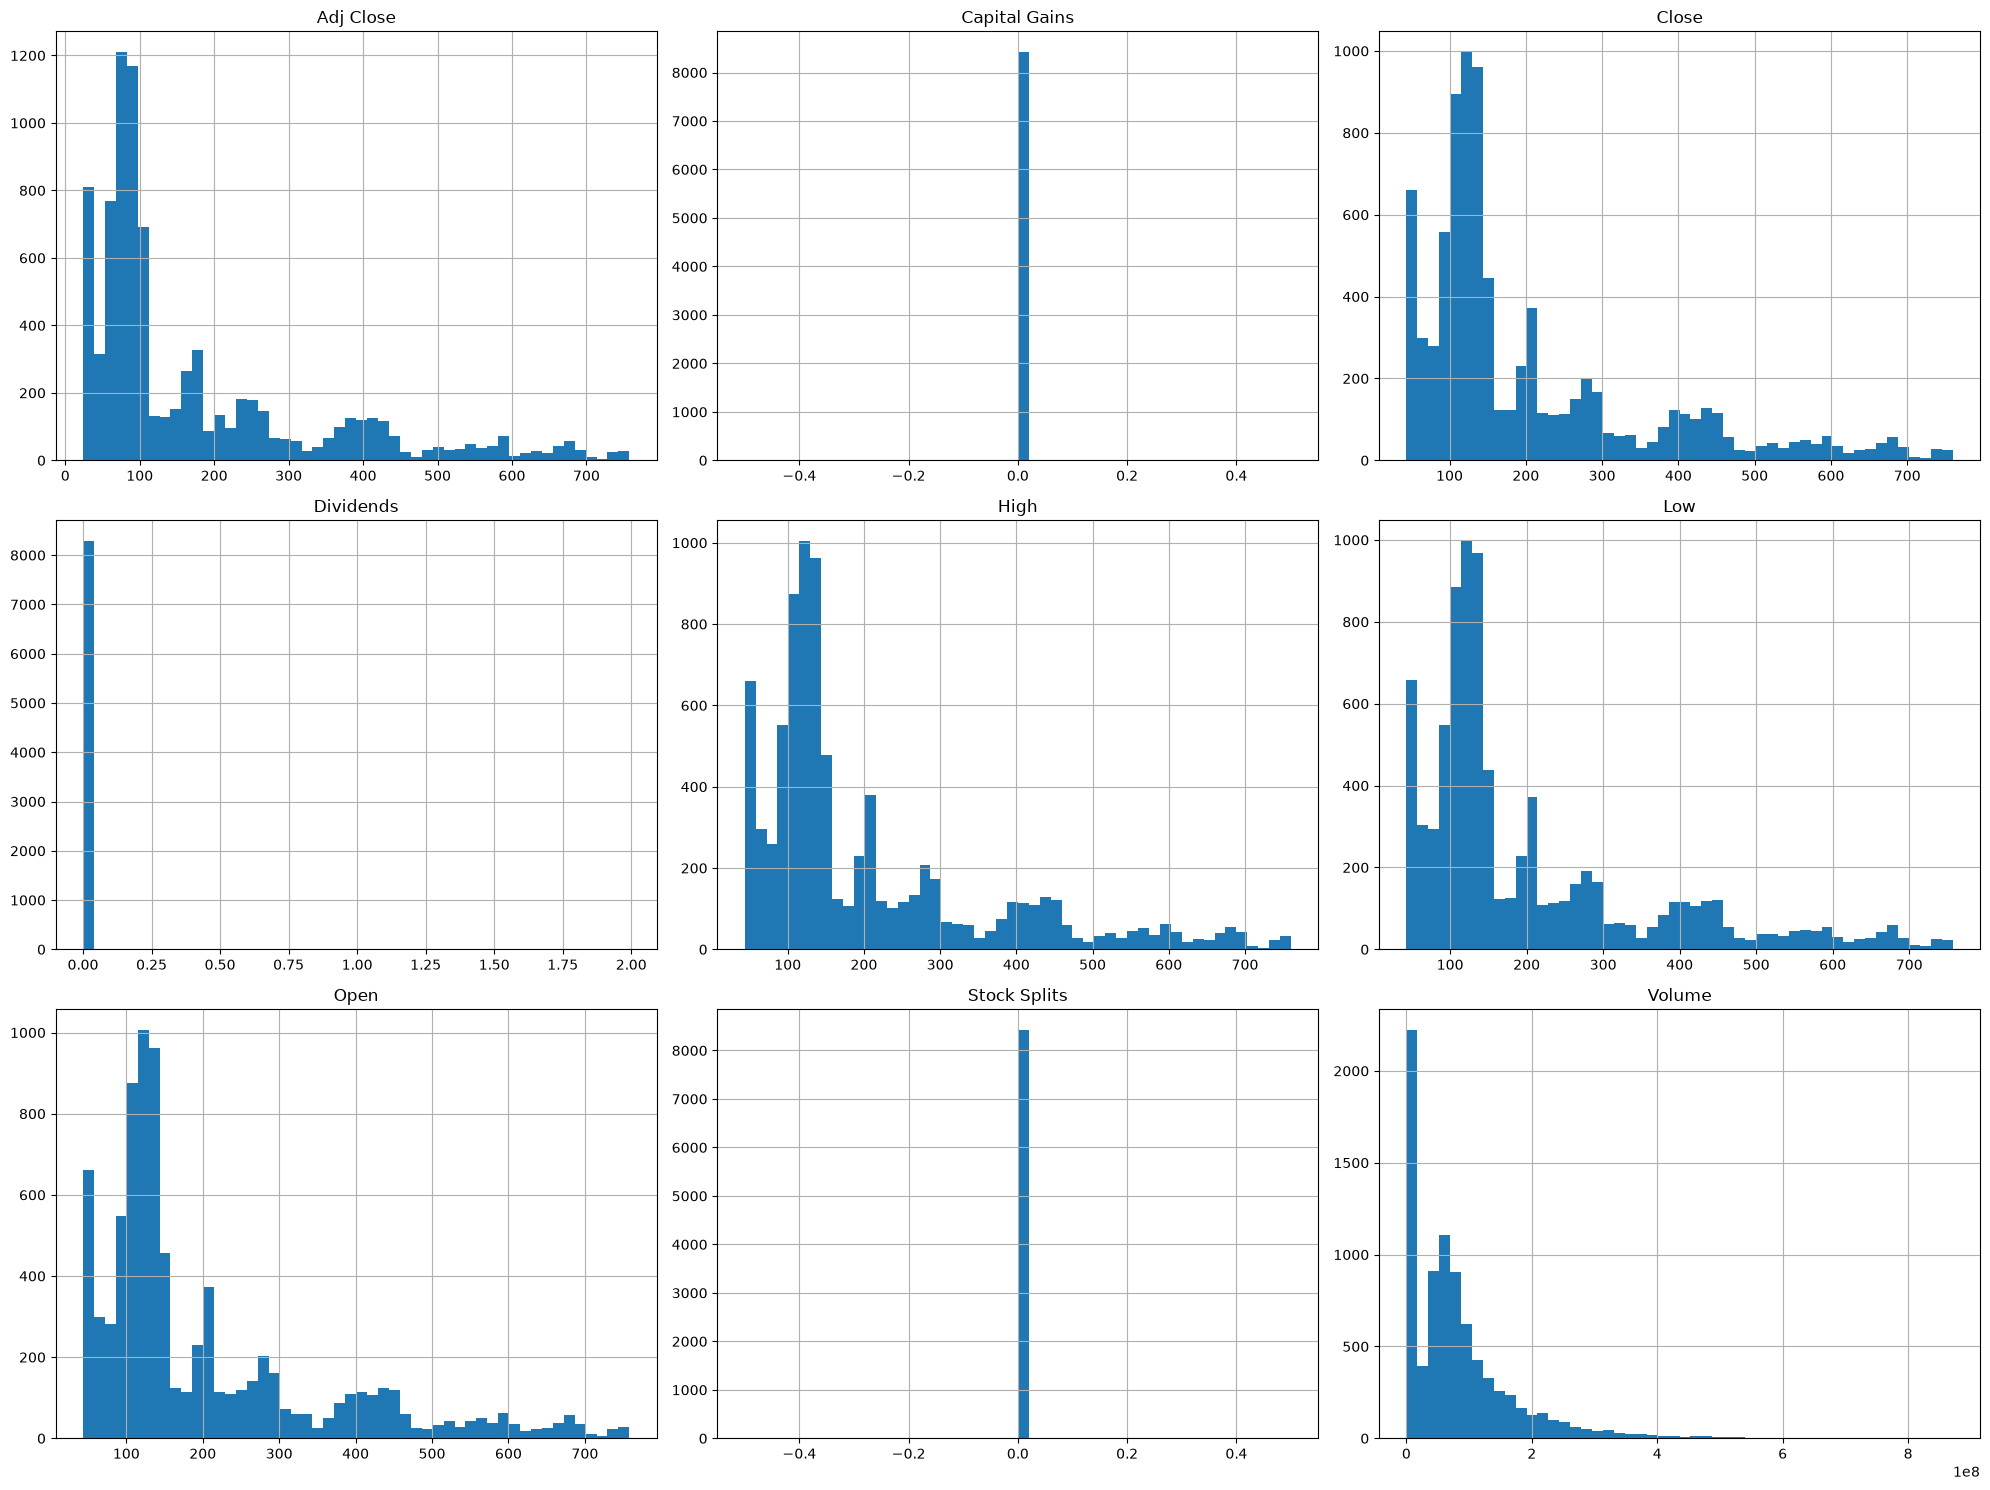

In [ ]:
# Generate histogram plots for each variable in SPY raw data. 

raw_prices.hist(bins=50, figsize=(20, 15))
save_fig(f"{SYMBOL}_attribute_histogram_plots")

plt.show()

Saving figure SPY_daily_high_price


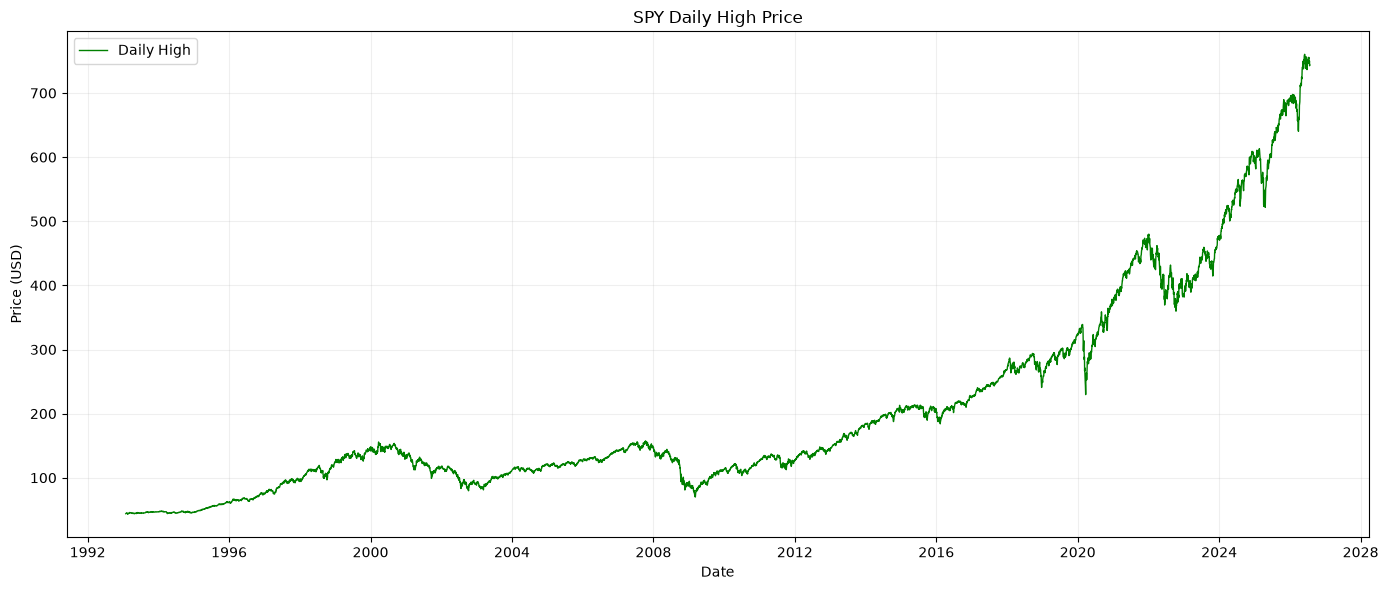

In [16]:
# Create Line Plot for Daily High Price of SPY.  
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    raw_prices.index,
    raw_prices["High"],
    label="Daily High",
    color="green",
    linewidth=1
)

ax.set_title("SPY Daily High Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(alpha=0.2)

save_fig(f"{SYMBOL}_daily_high_price")

plt.show()

Saving figure SPY_daily_low_price


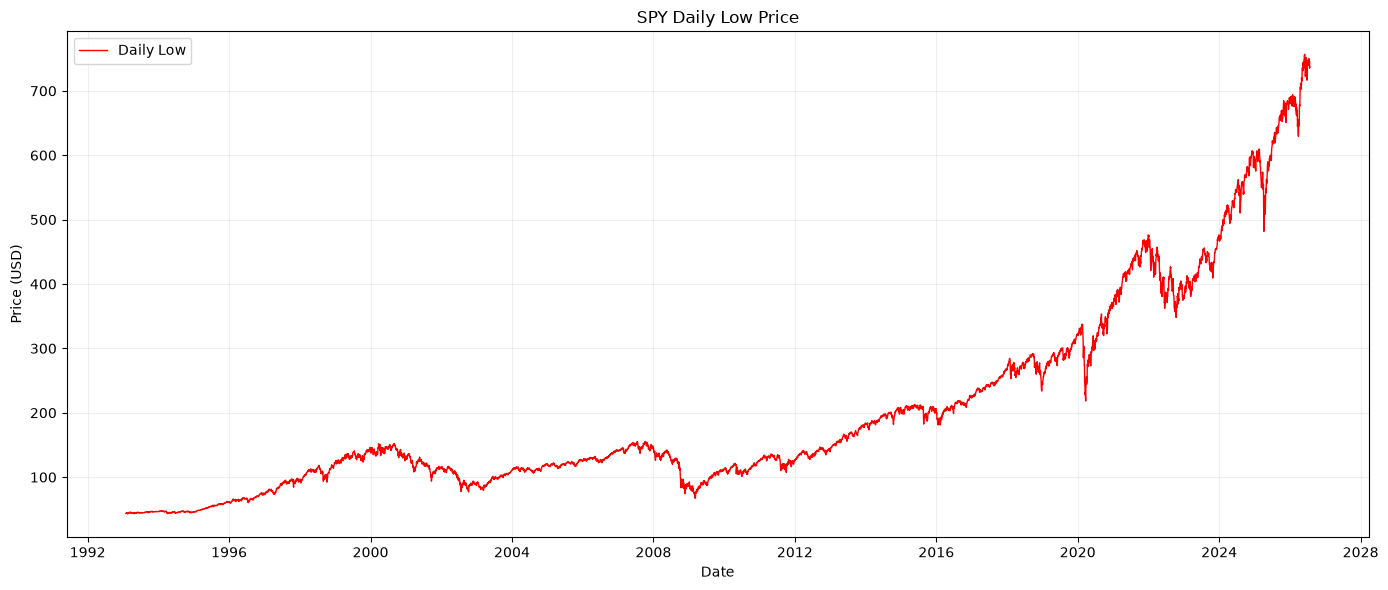

In [17]:
# Create Line Plot for Daily Low Price of SPY.  
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    raw_prices.index,
    raw_prices["Low"],
    label="Daily Low",
    color="red",
    linewidth=1
)

ax.set_title("SPY Daily Low Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(alpha=0.2)

save_fig(f"{SYMBOL}_daily_low_price")

plt.show()

Saving figure SPY_daily_high_low_spread


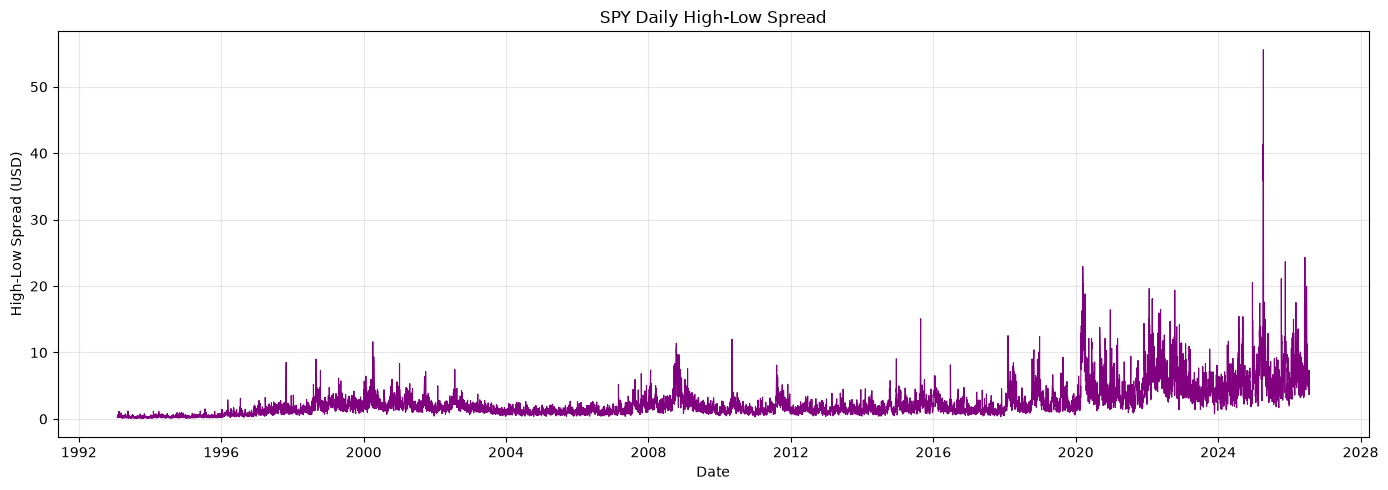

In [21]:
# Examine the Gap Between Daily High and Low of SPY Over Time. 

raw_prices["High_Low_Spread"] = raw_prices["High"] - raw_prices["Low"]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    raw_prices.index,
    raw_prices["High_Low_Spread"],
    color="purple",
    linewidth=0.8,
)

ax.set_title("SPY Daily High-Low Spread")
ax.set_xlabel("Date")
ax.set_ylabel("High-Low Spread (USD)")
ax.grid(alpha=0.3)

save_fig(f"{SYMBOL}_daily_high_low_spread")

plt.show()

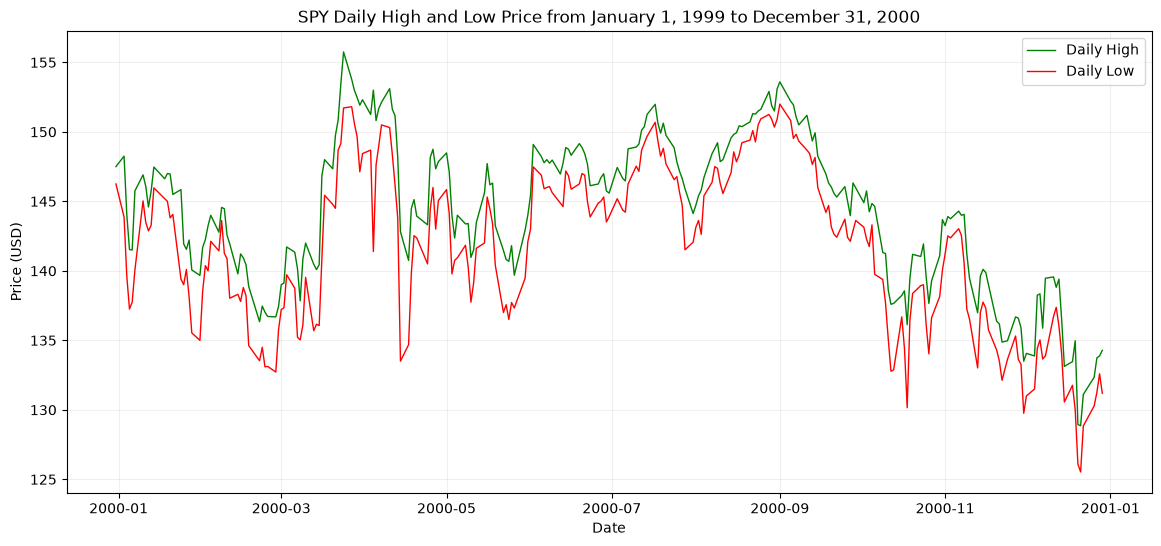

In [ ]:
# Notice that there were periods with large difference between daily high and low. 

# First examine graphs of SPY daily high and low in 2000, which corresponds to the dot-com bubble period.
start_date_1 = "1999-12-31"
end_date_1 = "2000-12-31"

plot_data_1 = raw_prices.loc[start_date_1:end_date_1]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    plot_data_1.index,
    plot_data_1["High"],
    label="Daily High",
    color="green",
    linewidth=1
)

ax.plot(
    plot_data_1.index,
    plot_data_1["Low"],
    label="Daily Low",
    color="red",
    linewidth=1
)

ax.set_title("SPY Daily High and Low Price from January 1, 1999 to December 31, 2000")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(alpha=0.2)

plt.show()

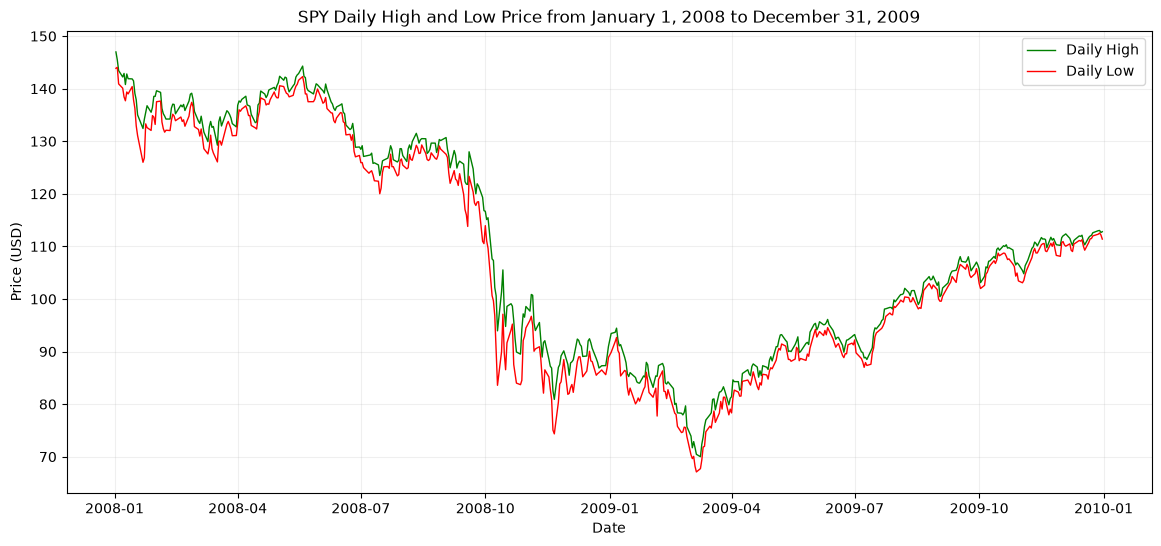

In [29]:
# Next, examine graphs of SPY daily high and low in 2008-2009, which corresponds to the financial crisis. 
start_date_2 = "2008-01-01"
end_date_2 = "2009-12-31"

plot_data_2 = raw_prices.loc[start_date_2:end_date_2]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    plot_data_2.index,
    plot_data_2["High"],
    label="Daily High",
    color="green",
    linewidth=1
)

ax.plot(
    plot_data_2.index,
    plot_data_2["Low"],
    label="Daily Low",
    color="red",
    linewidth=1
)

ax.set_title("SPY Daily High and Low Price from January 1, 2008 to December 31, 2009")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(alpha=0.2)

plt.show()

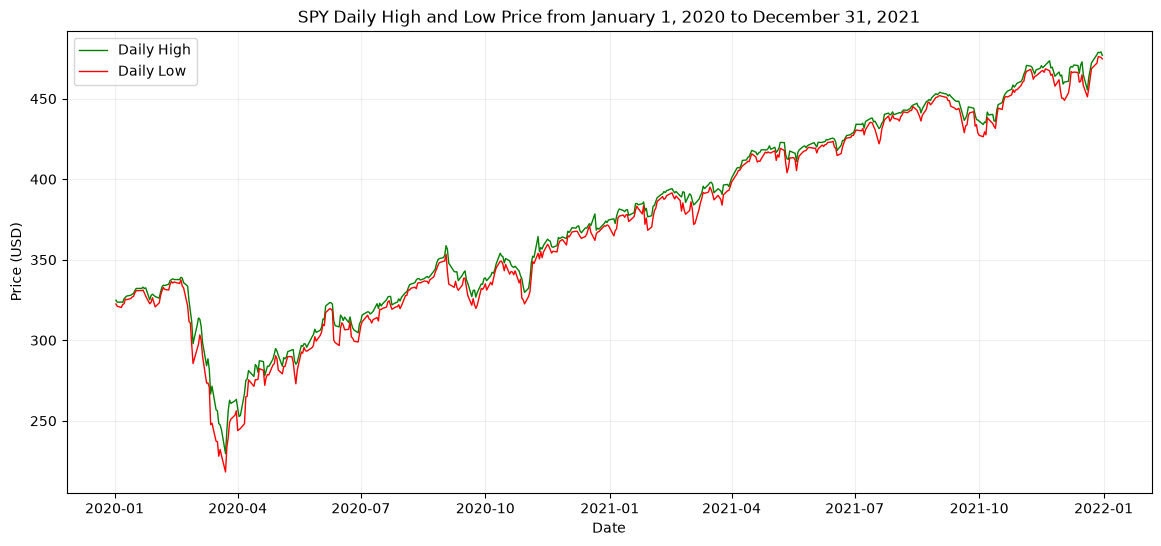

In [30]:
# Lastly, examine graphs of SPY daily high and low in 2020-2021, which corresponds to COVID-19 pandemic. 
start_date_3 = "2020-01-01"
end_date_3 = "2021-12-31"

plot_data_3 = raw_prices.loc[start_date_3:end_date_3]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    plot_data_3.index,
    plot_data_3["High"],
    label="Daily High",
    color="green",
    linewidth=1
)

ax.plot(
    plot_data_3.index,
    plot_data_3["Low"],
    label="Daily Low",
    color="red",
    linewidth=1
)

ax.set_title("SPY Daily High and Low Price from January 1, 2020 to December 31, 2021")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(alpha=0.2)

plt.show()